In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../notebooks/DATA/rock_density_xray.csv')

In [3]:
df.head()

,Rebound Signal Strength nHz,Rock Density kg/m3
0,72.945124,2.456548
1,14.229877,2.601719
2,36.597334,1.967004
3,9.578899,2.300439
4,21.765897,2.452374


In [4]:
df.columns = ['signal', 'density']

<Axes: xlabel='signal', ylabel='density'>

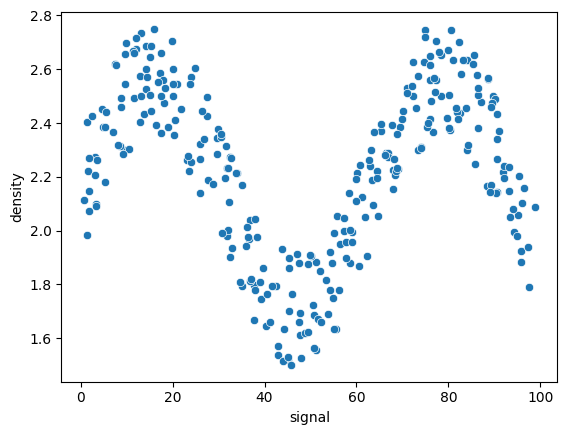

In [5]:
sns.scatterplot(x='signal', y='density', data=df)

In [16]:
X = df['signal'].values.reshape(-1,1)
y = df['density']

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [19]:
from sklearn.linear_model import LinearRegression

In [20]:
lin_model = LinearRegression()

In [21]:
lin_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
lin_pred = lin_model.predict(X_test)

In [23]:
lin_pred

array([2.21881855, 2.20065352, 2.21472324, 2.21799439, 2.20901592,
       2.21894912, 2.22381933, 2.21787738, 2.20368222, 2.2034435 ,
       2.22610239, 2.2004913 , 2.23485715, 2.24374317, 2.22322118,
       2.2158634 , 2.20285925, 2.22864354, 2.21659998, 2.23722892,
       2.20802066, 2.24431374, 2.20739768, 2.20614465, 2.19981917,
       2.23643331, 2.19917144, 2.25415309, 2.2100169 , 2.20405209])

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [27]:
mean_absolute_error(y_test, lin_pred)

0.24102551432457792

In [28]:
signal_range = np.arange(0,100)

In [29]:
signal_preds = lin_model.predict(signal_range.reshape(-1,1))

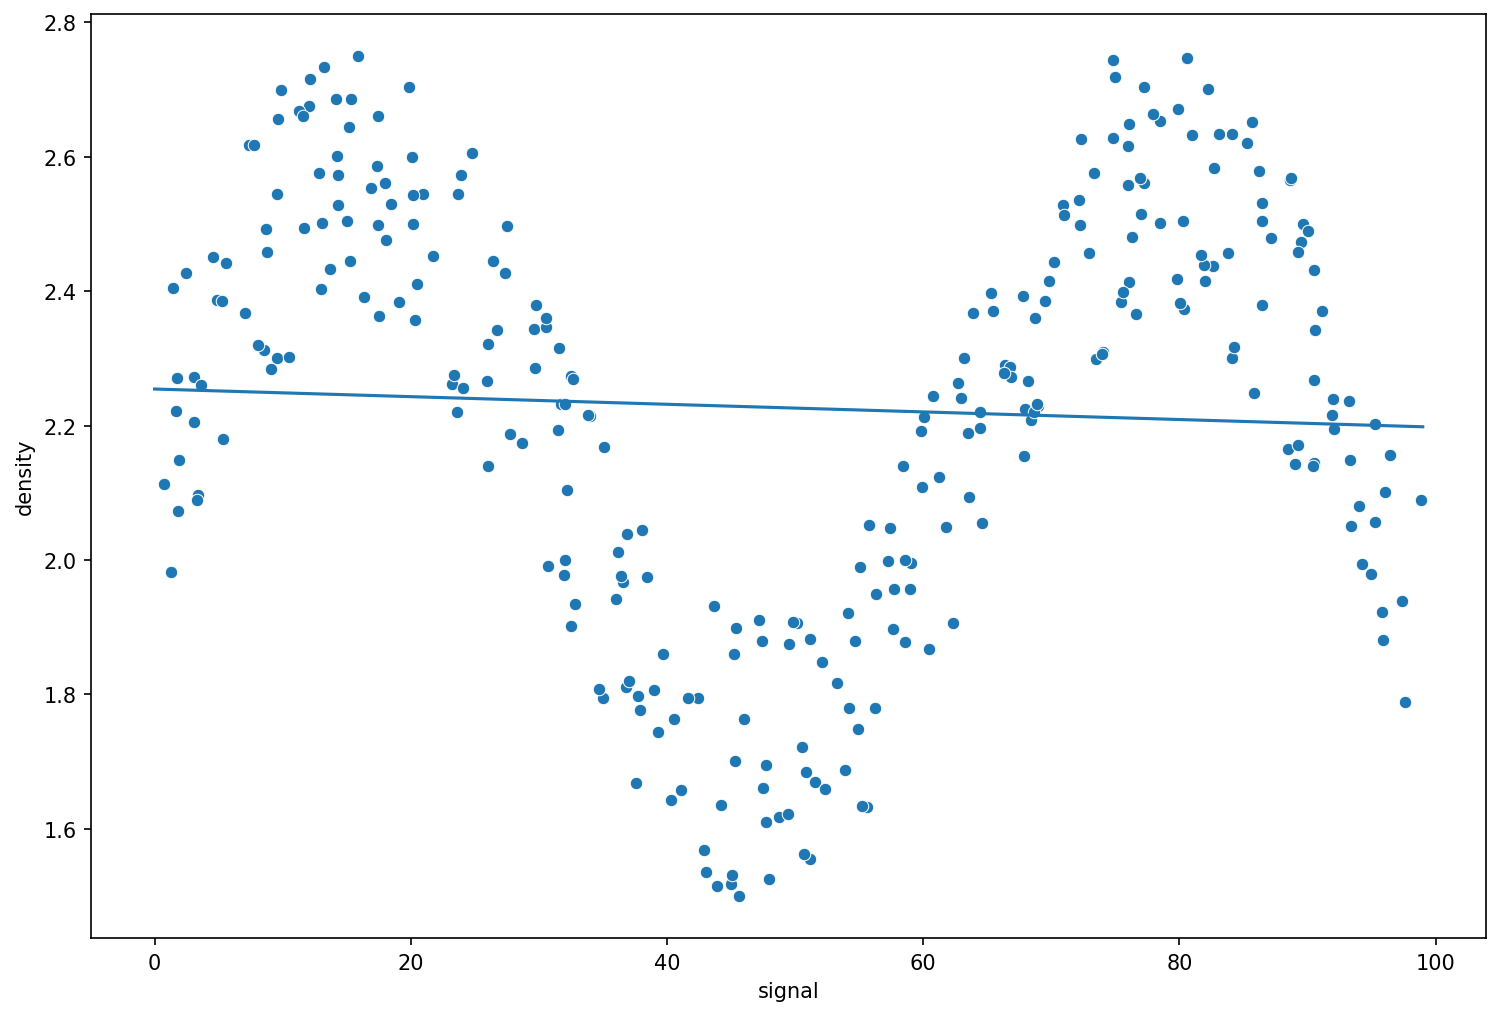

In [31]:
plt.figure(figsize=(12,8), dpi=150)
sns.scatterplot(x='signal', y='density', data=df)

plt.plot(signal_range, signal_preds)

In [35]:
residuals = y_test-lin_pred

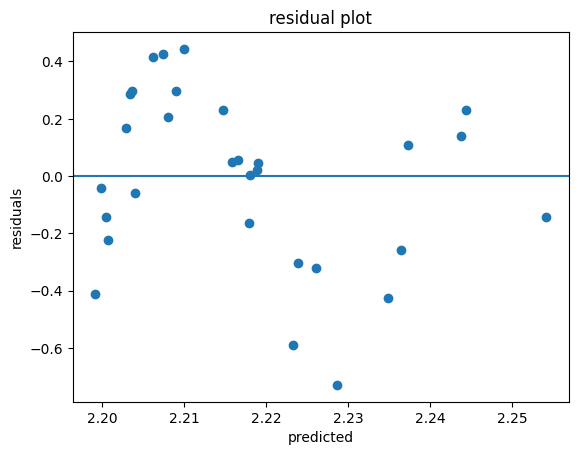

In [37]:
plt.scatter(lin_pred, residuals)

plt.axhline(y=0)

plt.xlabel("predicted")
plt.ylabel("residuals")
plt.title("residual plot")

plt.show()    

In [59]:
def run_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print(f'RMSE: {rmse}')
    mae = mean_absolute_error(y_test, preds)
    print(f'MAE: {mae}')

    signal_range = np.arange(0,100)
    signal_preds = model.predict(signal_range.reshape(-1,1))

    plt.figure(figsize=(12,8), dpi=100)
    sns.scatterplot(x='signal', y='density', data=df, color='red')

    plt.plot(signal_range, signal_preds)

RMSE: 0.29635030529174805
MAE: 0.24102551432457792


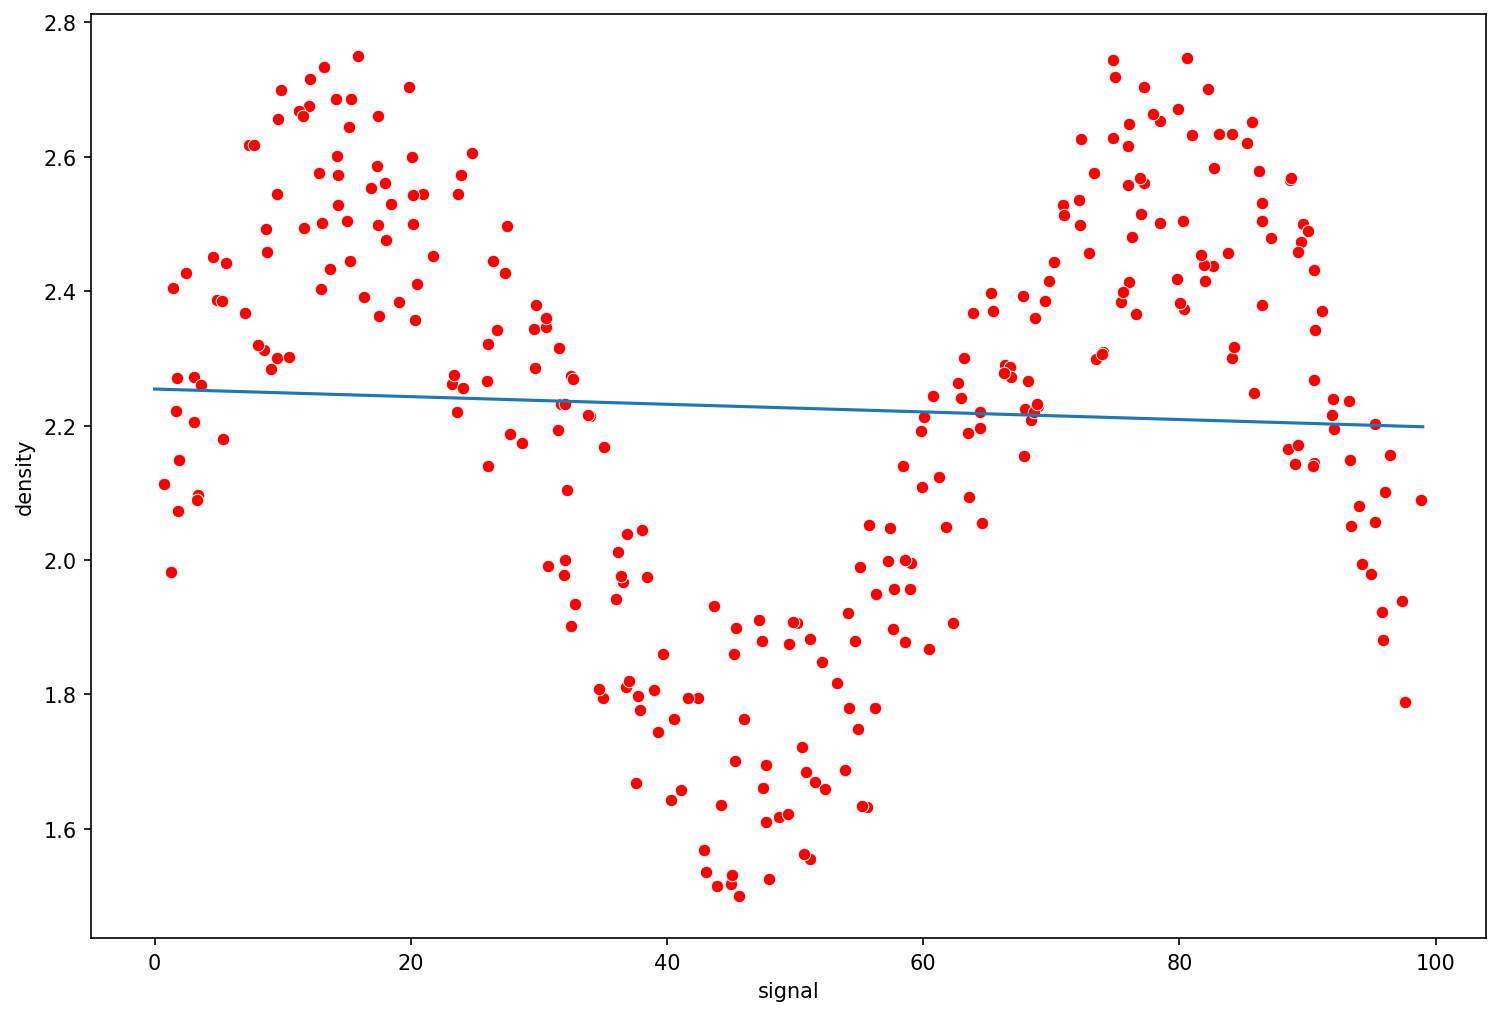

In [46]:
model = LinearRegression()
run_model(model, X_train, y_train, X_test, y_test)

In [48]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

RMSE: 0.14027772941373468
MAE: 0.11791958867219382


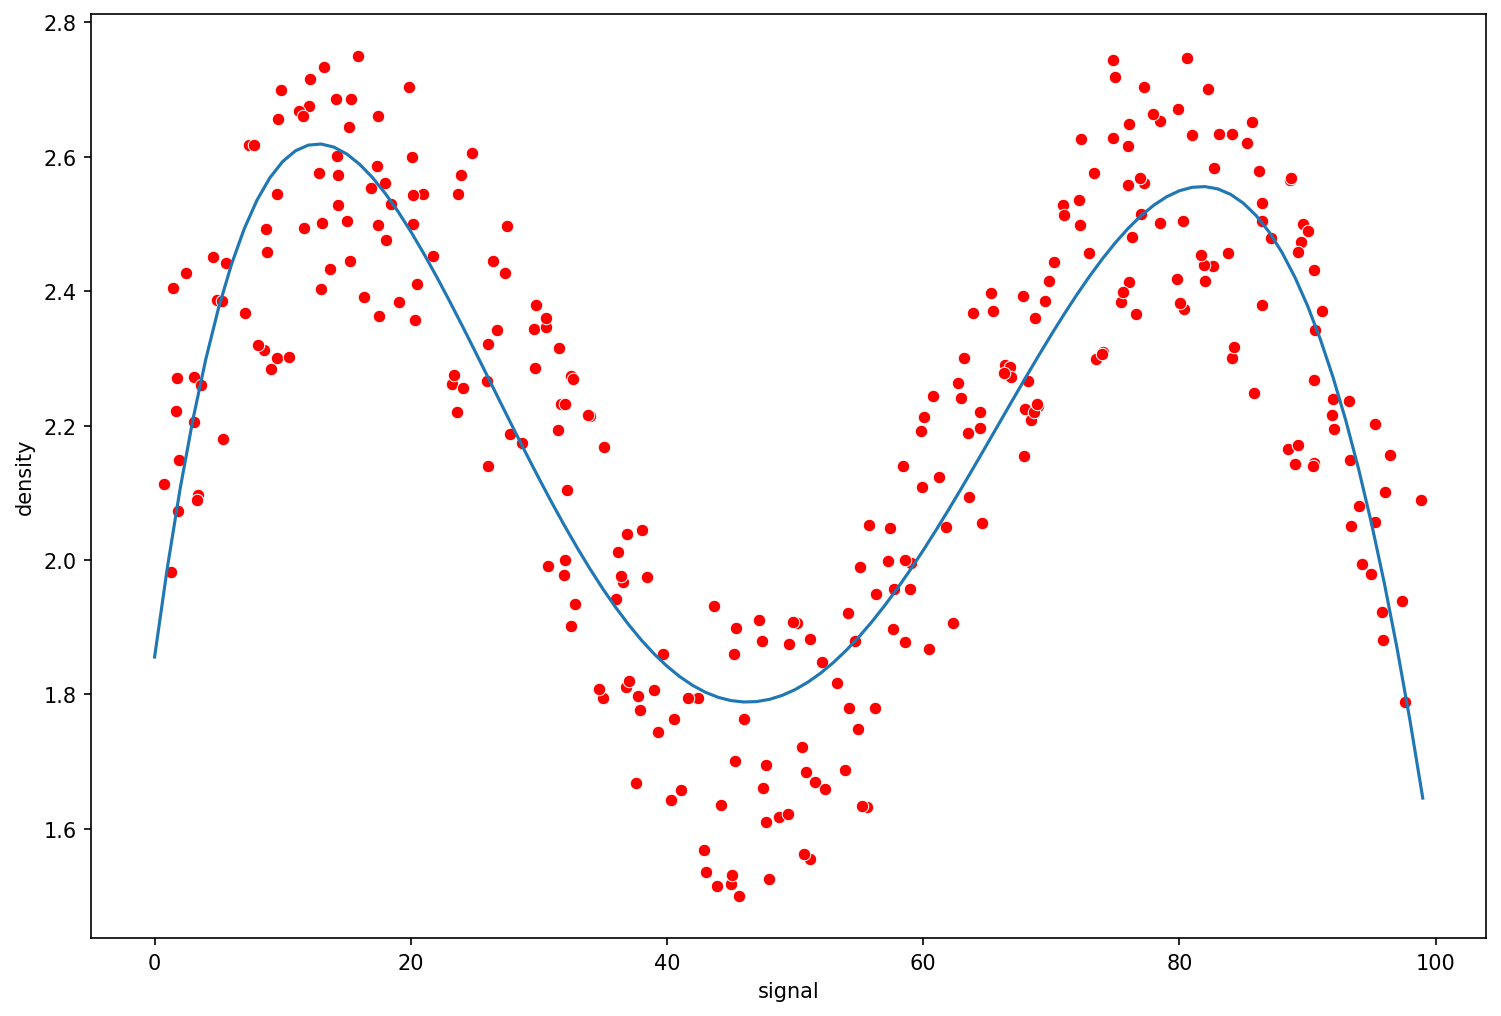

In [54]:
pipe = make_pipeline(PolynomialFeatures(degree=5), LinearRegression())
run_model(pipe, X_train, y_train, X_test, y_test)

In [55]:
from sklearn.neighbors import KNeighborsRegressor

RMSE: 0.14419338115267671
MAE: 0.125157895328941
RMSE: 0.14031476832218073
MAE: 0.12369705472800557
RMSE: 0.1389085595310869
MAE: 0.12000896423683943


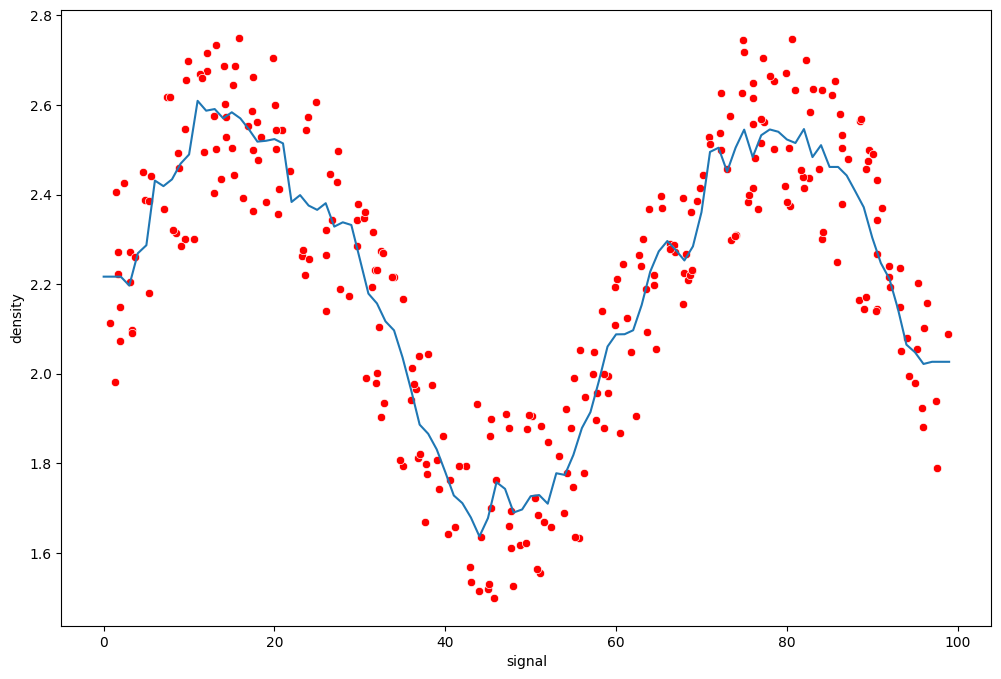

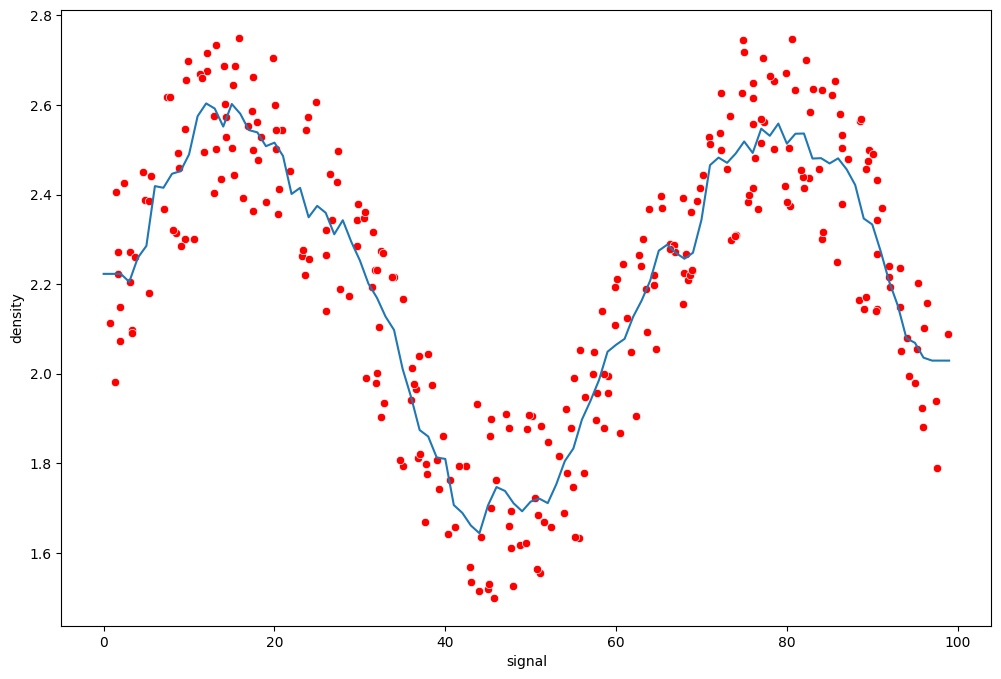

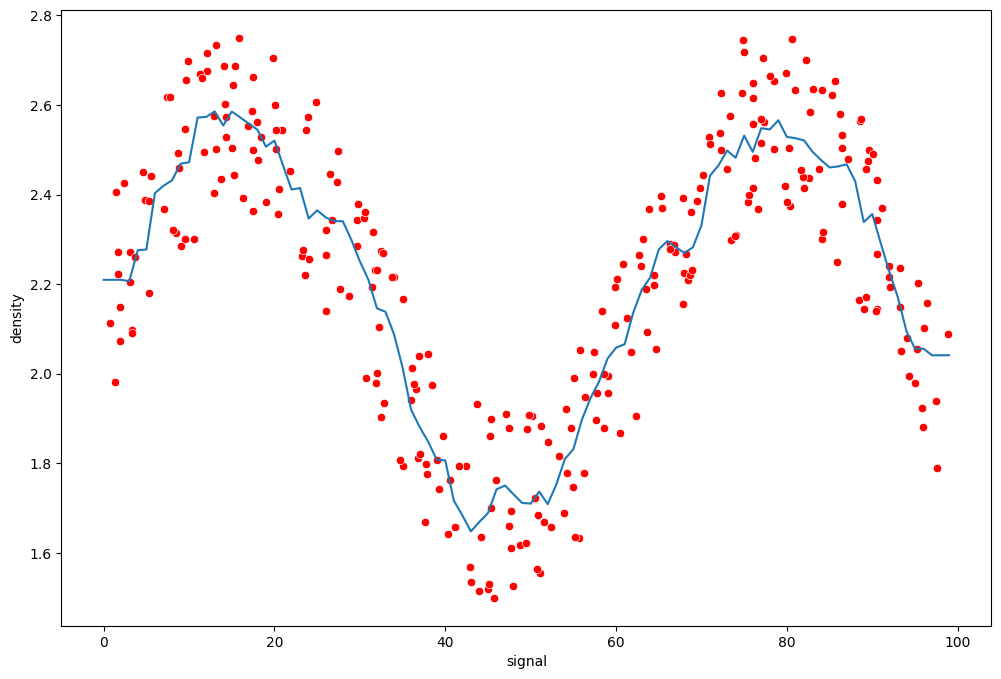

In [62]:
k_values=[8,9,10]

for n in k_values:
    model = KNeighborsRegressor(n_neighbors=n)
    run_model(model, X_train, y_train, X_test, y_test)

In [63]:
from sklearn.tree import DecisionTreeRegressor

RMSE: 0.16707571608725927
MAE: 0.1206619084399996


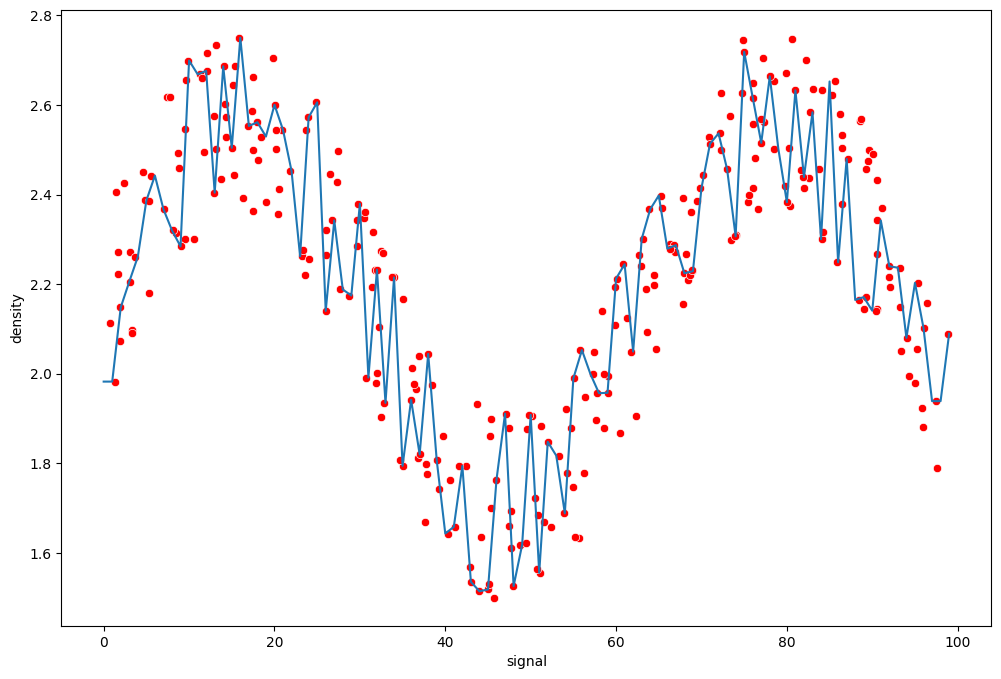

In [65]:
model = DecisionTreeRegressor()
run_model(model, X_train, y_train, X_test, y_test)

In [66]:
from sklearn.svm import SVR

In [67]:
from sklearn.model_selection import GridSearchCV

In [70]:
svr = SVR()

param_grid = {"C": [0, 0.1, 0.01, 1, 5, 100, 1000],
              "gamma": ['auto','scale']}

grid = GridSearchCV(svr, param_grid)

C:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
10 fits failed out of a total of 70.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Users

RMSE: 0.141542431349303
MAE: 0.12672177161621226


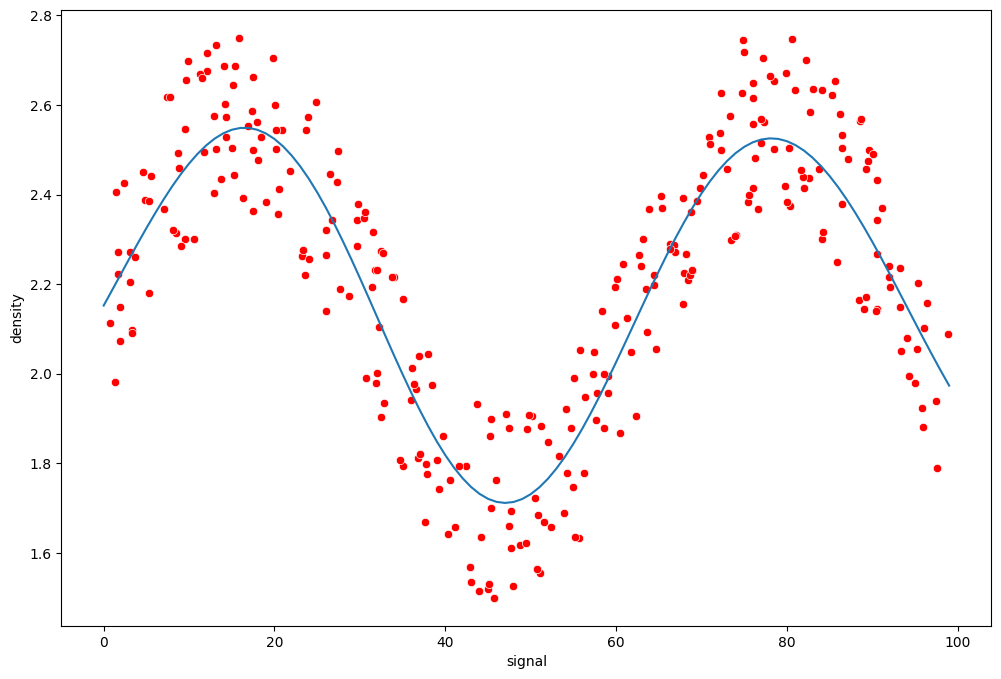

In [71]:
run_model(grid, X_train, y_train, X_test, y_test)

In [72]:
from sklearn.ensemble import RandomForestRegressor

RMSE: 0.16053875950288124
MAE: 0.1314899858063293


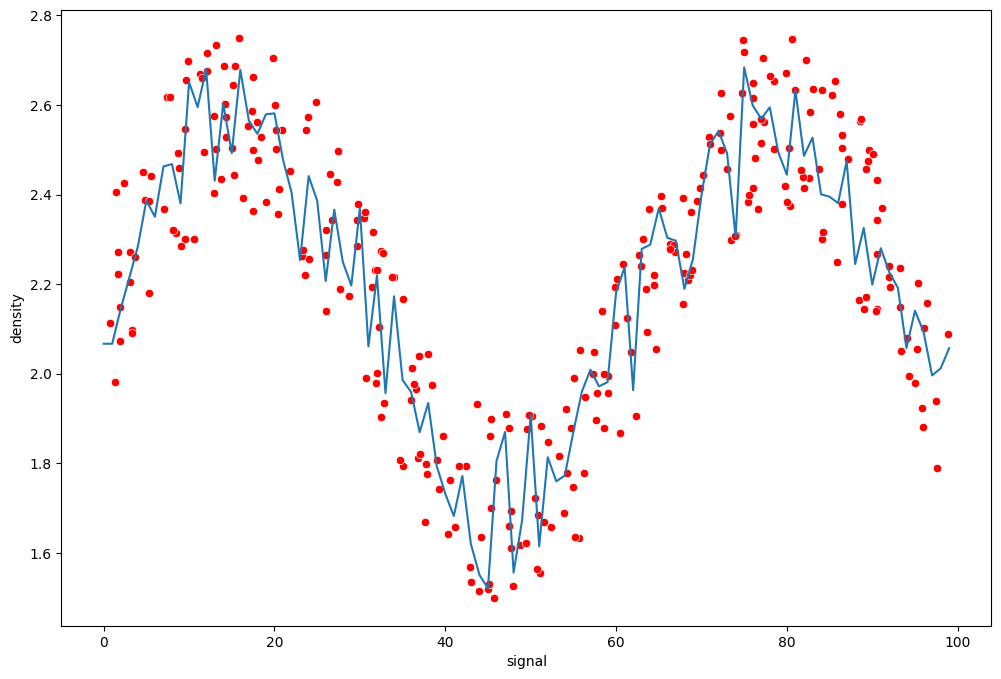

In [73]:
rfr = RandomForestRegressor(n_estimators=10)
run_model(rfr, X_train, y_train, X_test, y_test)

In [74]:
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor

RMSE: 0.14536433248271918
MAE: 0.12703399592995443


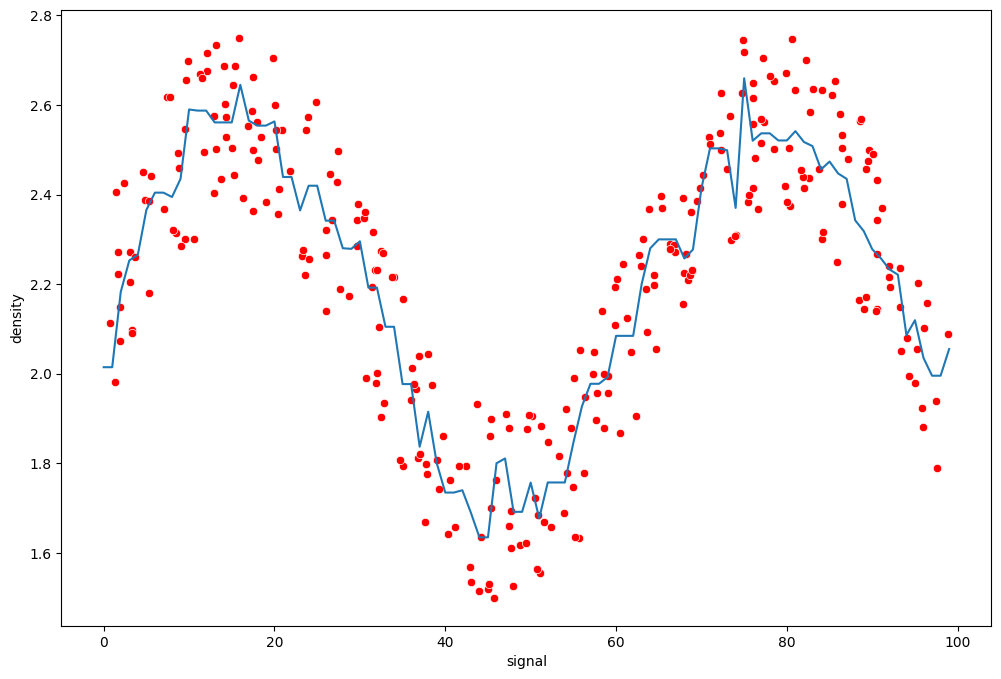

In [75]:
model = GradientBoostingRegressor()
run_model(model, X_train, y_train, X_test, y_test)

RMSE: 0.1453493676880177
MAE: 0.12811414544715388


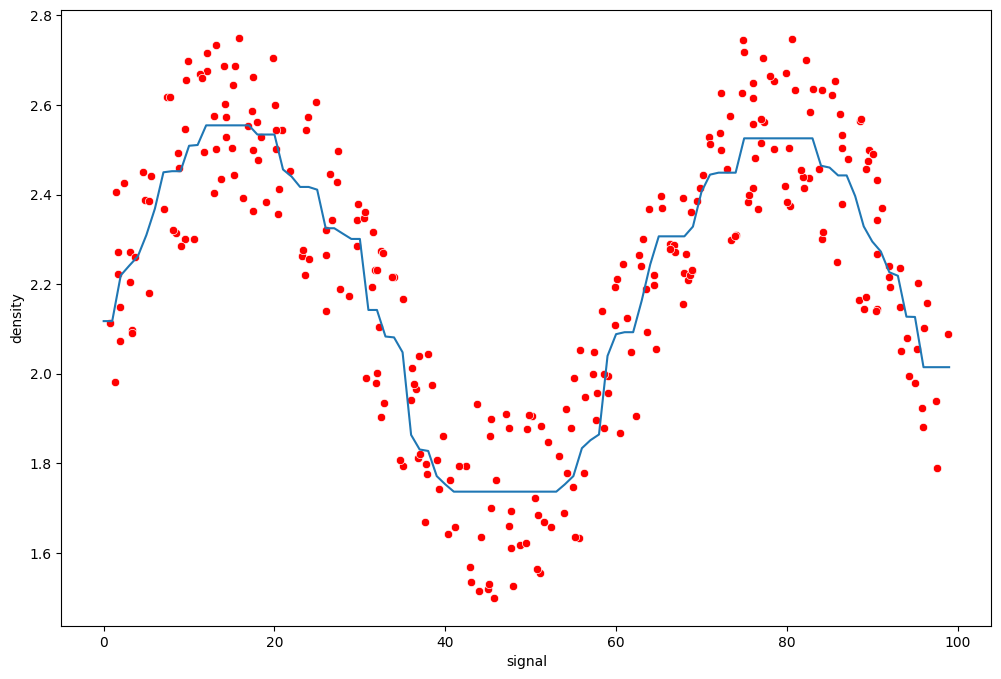

In [76]:
model = AdaBoostRegressor()
run_model(model, X_train, y_train, X_test, y_test)